# Import Libraries


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [19]:

# Load dataset
df = pd.read_csv("/content/nvidia.csv")



# 1. basic Exploration
print(df.info())
print(df.describe())

DATA_PATH = "/content/nvidia.csv"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1260 non-null   object 
 1   Open       1260 non-null   float64
 2   High       1260 non-null   float64
 3   Low        1260 non-null   float64
 4   Close      1260 non-null   float64
 5   Adj Close  1260 non-null   float64
 6   Volume     1260 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 69.0+ KB
None
              Open         High          Low        Close    Adj Close  \
count  1260.000000  1260.000000  1260.000000  1260.000000  1260.000000   
mean    236.259629   240.632726   231.748678   236.457376   236.246529   
std     203.974380   207.537564   200.074702   204.085654   204.154064   
min      33.977501    34.367500    33.150002    33.445000    33.255783   
25%     116.956251   121.027501   114.323750   116.508123   116.403095   
50%     168.160004   1

# EDA

In [13]:
# ==========================================
# 1. EDA & PREPROCESSING SECTION
# ==========================================
def run_eda_and_preprocess():
    print("\n--- Phase 1: EDA & Preprocessing ---")
    df = pd.read_csv(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df = df.sort_index()

    # --- EDA GRAPHS ---
    # 1. Price Trend
    plt.figure(figsize=(12,5))
    plt.plot(df['Close'], color='green')
    plt.title("Nvidia Closing Price Trend")
    save_plot("eda_price_trend")

    # 2. Correlation Heatmap
    plt.figure(figsize=(10,6))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title("Feature Correlation Heatmap")
    save_plot("eda_correlation")

    # --- FEATURE ENGINEERING ---
    df['MA10'] = df['Close'].rolling(window=10).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df['Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Return'].rolling(window=10).std()
    df['Lag1'] = df['Close'].shift(1)
    df['Lag2'] = df['Close'].shift(2)

    # Target: We want to predict the next day's price
    df["Target"] = df["Close"].shift(-1)

    # Handle missing values from rolling windows
    df.ffill(inplace=True)
    df.dropna(inplace=True)

    # 3. Moving Average Visualization
    plt.figure(figsize=(12,5))
    plt.plot(df['Close'], label='Price', alpha=0.5)
    plt.plot(df['MA50'], label='50-Day MA', color='red')
    plt.title("Price vs Moving Average")
    plt.legend()
    save_plot("eda_moving_average")

    df.to_csv(PROCESSED_PATH)
    return df


# Model Training (XGBoost)

In [14]:

# MODEL TRAINING
def train_model(df):
    print("\n--- Phase 2: Model Training ---")

    # Define Features and Target
    X = df.drop(columns=["Target"])
    y = df["Target"]

    # Time-Series Split (90% Train / 10% Test)
    split = int(len(df) * 0.9)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Scaling - Crucial: Fit ONLY on train data
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # XGBoost Regressor
    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train_scaled, y_train,
        eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
        verbose=100
    )

    # Save Pickle Files
    with open(MODEL_PATH, 'wb') as f: pickle.dump(model, f)
    with open(SCALER_PATH, 'wb') as f: pickle.dump(scaler, f)

    return model, scaler, X_test_scaled, y_test, X.columns



# Evaluation and Testing


In [15]:
# 3. EVALUATION SECTION
def evaluate_model(model, scaler, X_test_scaled, y_test, feature_names):
    print("\n--- Phase 3: Evaluation ---")
    y_pred = model.predict(X_test_scaled)

    # Calculate Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"METRICS >> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

    # --- EVALUATION GRAPHS ---

    # 1. Actual vs Predicted
    plt.figure(figsize=(12,6))
    plt.plot(y_test.values, label="Actual Price", color='blue', linewidth=1.5)
    plt.plot(y_pred, label="XGBoost Prediction", color='orange', linestyle='--')
    plt.title("Final Model: Actual vs Predicted Prices")
    plt.legend()
    save_plot("eval_actual_vs_pred")

    # 2. Feature Importance
    plt.figure(figsize=(10,6))
    importances = model.feature_importances_
    sns.barplot(x=importances, y=feature_names, palette='viridis')
    plt.title("XGBoost Feature Importance")
    save_plot("eval_feature_importance")

    # 3. Residual Error
    plt.figure(figsize=(8,5))
    residuals = y_test.values - y_pred
    sns.histplot(residuals, kde=True, color='purple')
    plt.title("Residual Error Distribution")
    save_plot("eval_residuals")

    # 4. Metrics Bar Chart
    plt.figure(figsize=(6,4))
    metric_names = ['RMSE', 'MAE']
    metric_values = [rmse, mae]
    sns.barplot(x=metric_names, y=metric_values)
    plt.title("Error Metrics Summary")
    save_plot("eval_metrics_summary")



--- Phase 1: EDA & Preprocessing ---
[INFO] Graph saved to reports/eda_price_trend.png


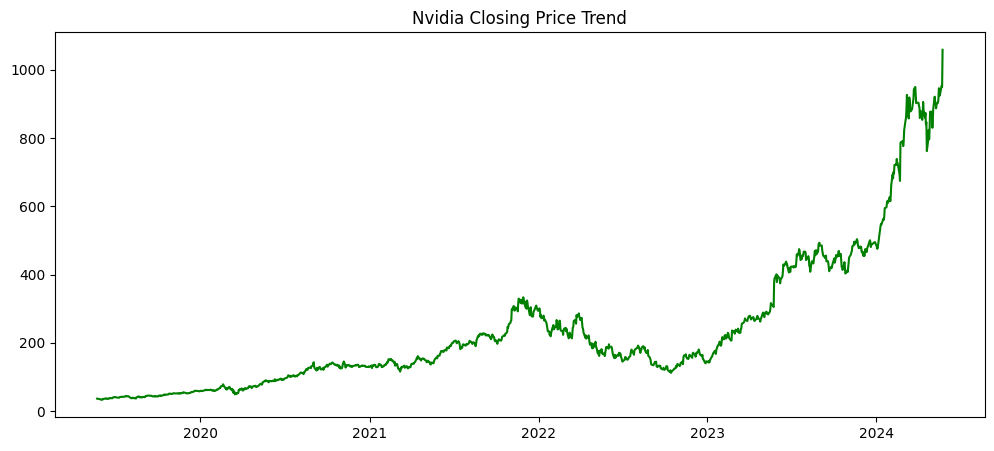

[INFO] Graph saved to reports/eda_correlation.png


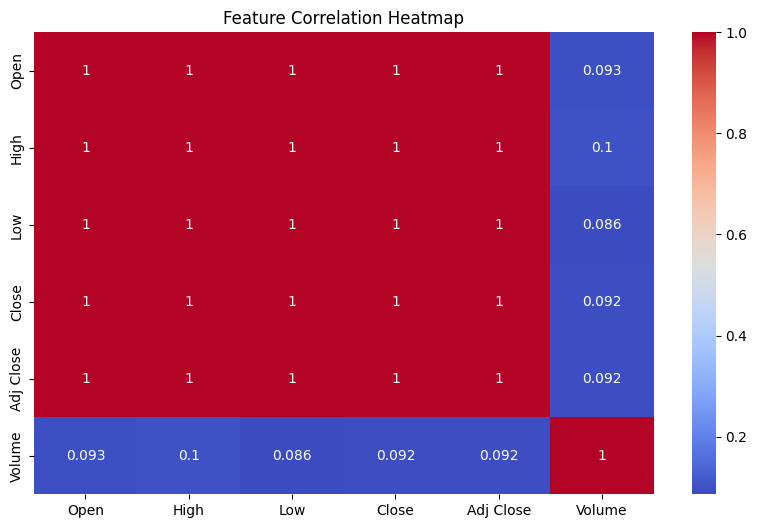

[INFO] Graph saved to reports/eda_moving_average.png


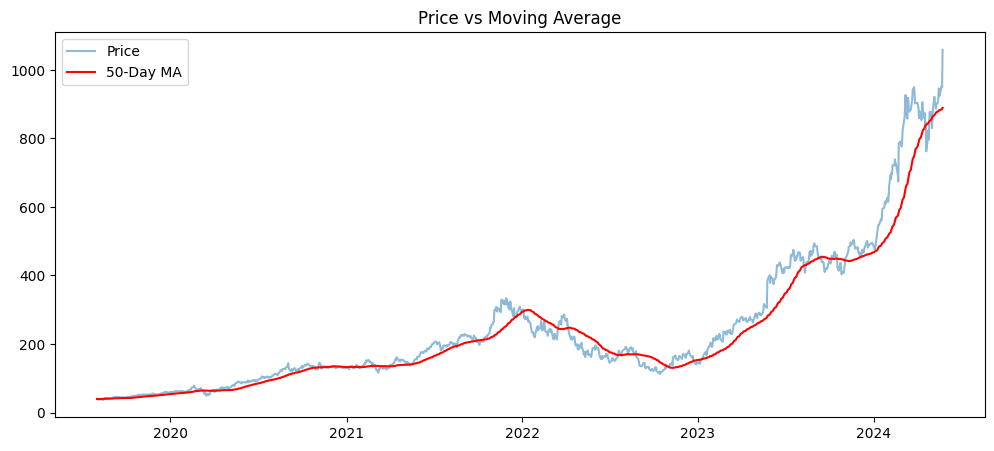


--- Phase 2: Model Training ---
[0]	validation_0-rmse:114.86013	validation_1-rmse:570.87182
[100]	validation_0-rmse:43.45109	validation_1-rmse:412.14058
[200]	validation_0-rmse:17.19286	validation_1-rmse:347.67259
[300]	validation_0-rmse:7.71395	validation_1-rmse:326.35402
[400]	validation_0-rmse:4.30904	validation_1-rmse:318.40865
[500]	validation_0-rmse:3.01164	validation_1-rmse:316.28186
[600]	validation_0-rmse:2.42189	validation_1-rmse:315.25659
[700]	validation_0-rmse:2.09645	validation_1-rmse:314.75654
[800]	validation_0-rmse:1.86760	validation_1-rmse:314.48907
[900]	validation_0-rmse:1.68525	validation_1-rmse:314.46510
[999]	validation_0-rmse:1.53479	validation_1-rmse:314.40898

--- Phase 3: Evaluation ---
METRICS >> RMSE: 314.4090 | MAE: 263.2971 | R2: -2.2616
[INFO] Graph saved to reports/eval_actual_vs_pred.png


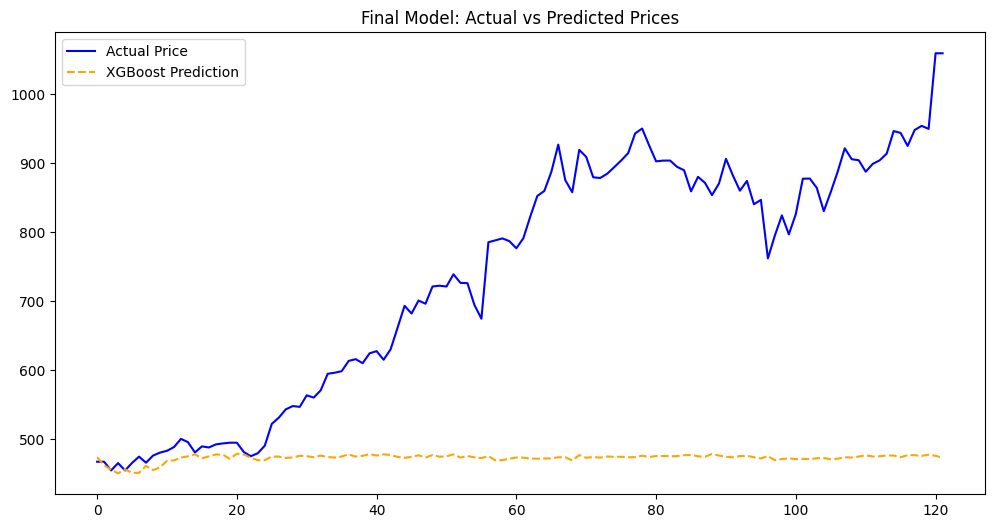

/tmp/ipykernel_6278/2317395819.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


[INFO] Graph saved to reports/eval_feature_importance.png


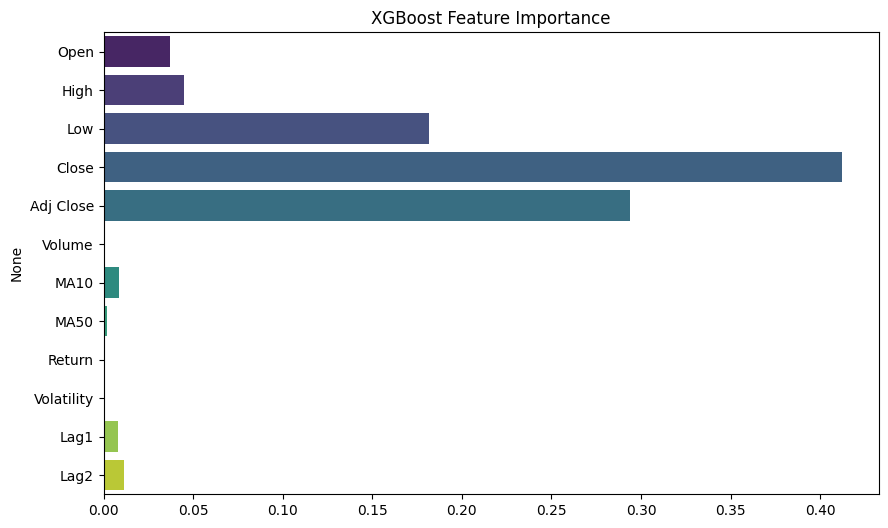

[INFO] Graph saved to reports/eval_residuals.png


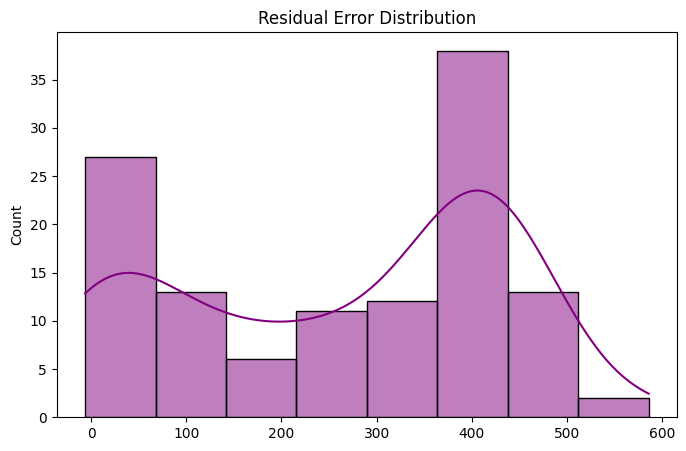

[INFO] Graph saved to reports/eval_metrics_summary.png


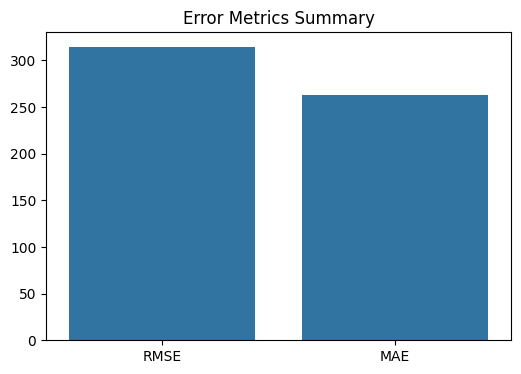


✅ Pipeline complete! Check the 'reports' folder for all visual artifacts.
Missing values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


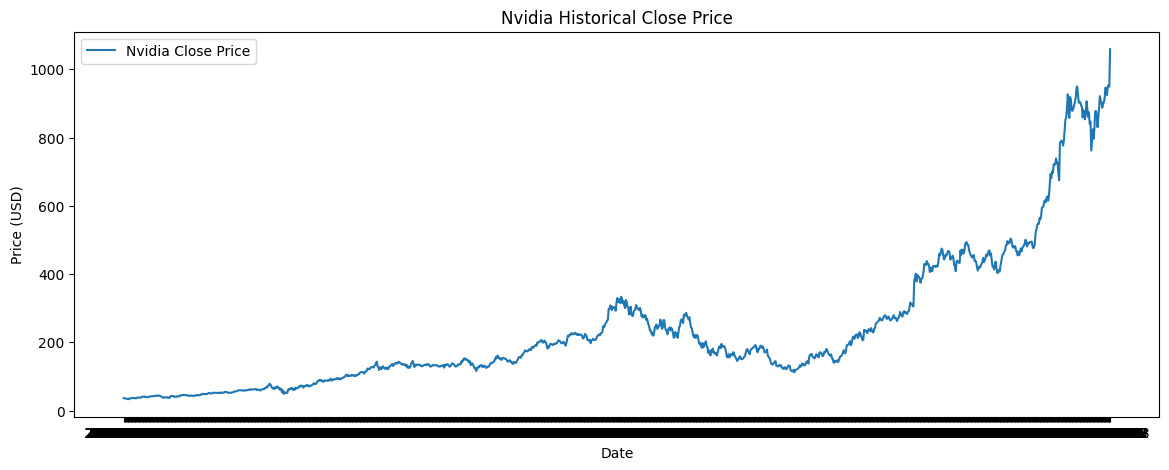

In [20]:

# MAIN EXECUTION
if __name__ == "__main__":
    # Run Preprocessing
    processed_df = run_eda_and_preprocess()

    # Run Training
    model, scaler, X_test_s, y_test, feat_names = train_model(processed_df)

    # Run Evaluation
    evaluate_model(model, scaler, X_test_s, y_test, feat_names)

    print("\n✅ Pipeline complete! Check the 'reports' folder for all visual artifacts.")

# 2. Check for missing values
print("Missing values:\n", df.isnull().sum())

# 3. Visualize the Closing Price over time
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], label='Nvidia Close Price')
plt.title('Nvidia Historical Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()